# Stage 3 — Fine-tuning SHViT on FGVC Aircraft

This notebook fine-tunes pretrained SHViT models (S1..S4) on FGVC Aircraft
using `finetune_shvit_fgvc_aircraft.py`. Data preprocessing follows
Tip-Adapter (`splits.py`, CLIP normalization, bicubic resize).

**Before running:** `Runtime → Change runtime type → T4 GPU`

### What this notebook does
1. Verifies GPU, mounts Drive (optional), prepares paths
2. Clones SHViT + this project repo, installs deps
3. Downloads SHViT pretrained weights (S1..S4)
4. Runs `finetune_shvit_fgvc_aircraft.py` for each variant
5. Plots training curves

All outputs land under `<OUT_ROOT>/Stage 3: fine-tuning SHViT/<variant>/`.


## 0. GPU check

In [1]:
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB


## 1. (Optional) Mount Drive

Persist the dataset, weights, and checkpoints across sessions.

In [2]:
USE_DRIVE = True

OUT_ROOT = '/content/CV_Research_Paper_FGVCAircraft'

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT   = '/content/drive/MyDrive/fgvc_aircraft_data'
    WEIGHTS_DIR = '/content/drive/MyDrive/shvit_weights'
    OUT_ROOT    = '/content/drive/MyDrive/CV_Research_Paper_FGVCAircraft'
else:
    DATA_ROOT   = '/content/fgvc_aircraft_data'
    WEIGHTS_DIR = '/content/weights'

OUTPUT_DIR = f'{OUT_ROOT}/Stage 3: fine-tuning SHViT'
WEIGHTS_PATH = f'{WEIGHTS_DIR}/shvit_s4.pth'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print('Data       :', DATA_ROOT)
print('Weights    :', WEIGHTS_PATH)
print('Output root:', OUT_ROOT)
print('Output dir :', OUTPUT_DIR)


Mounted at /content/drive
Data       : /content/drive/MyDrive/fgvc_aircraft_data
Weights    : /content/drive/MyDrive/shvit_weights/shvit_s4.pth
Output root: /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft
Output dir : /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft/Stage 3: fine-tuning SHViT


In [3]:
# Optional: copy the dataset to local SSD for faster I/O.
import shutil, os, time
src = '/content/drive/MyDrive/fgvc_aircraft_data'
dst = '/content/fgvc_aircraft_local'

if USE_DRIVE and not os.path.exists(dst) and os.path.isdir(src):
    print('Copying dataset to local SSD...')
    t0 = time.time()
    shutil.copytree(src, dst)
    print(f'done in {time.time()-t0:.0f}s')
    DATA_ROOT = dst
elif os.path.exists(dst):
    DATA_ROOT = dst
print('DATA_ROOT now:', DATA_ROOT)


Copying dataset to local SSD...
done in 0s
DATA_ROOT now: /content/fgvc_aircraft_local


## 2. Clone repos and install dependencies

In [4]:
import os, shutil

if not os.path.isdir('/content/SHViT'):
    !git clone https://github.com/ysj9909/SHViT.git /content/SHViT

REPO = '/content/Vision_Project_spring_26'
if not os.path.isdir(REPO):
    !git clone -b Vision_Project_spring_26_FGVCAircraft \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git {REPO}

for fname in [
    'Stage 3: fine-tuning SHViT/finetune_shvit_fgvc_aircraft.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
    'prepare_fgvc_aircraft.py',
]:
    shutil.copy(f'{REPO}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))

DATASETS_DST = '/content/datasets'
if os.path.isdir(DATASETS_DST):
    shutil.rmtree(DATASETS_DST)
shutil.copytree(f'{REPO}/datasets', DATASETS_DST)
print('Vendored datasets/ package.')


Cloning into '/content/SHViT'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 183 (delta 84), reused 82 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 168.52 KiB | 5.44 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 900, done.
remote: Counting objects: 100% (331/331), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 900 (delta 227), reused 210 (delta 160), pack-reused 569 (from 1)
Receiving objects: 100% (900/900), 461.98 MiB | 41.34 MiB/s, done.
Resolving deltas: 100% (470/470), done.
Copied: finetune_shvit_fgvc_aircraft.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: prepare_fgvc_aircraft.py
Vendored datasets/ package.


In [5]:
# Install SHViT deps (timm pinned, --no-deps so torch isn't downgraded).
# FGVC Aircraft uses its own canonical split files, so no gdown needed.
!pip install -q timm==0.5.4 --no-deps
!pip install -q einops==0.4.1 easydict
print('Dependencies installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 15.8 MB/s eta 0:00:00
Dependencies installed.


## 3. Download SHViT-S4 pretrained weights

In [6]:
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(WEIGHTS_PATH):
    !wget -q --show-progress \
        https://github.com/ysj9909/SHViT/releases/download/v1.0/shvit_s4.pth \
        -O {WEIGHTS_PATH}
size_mb = os.path.getsize(WEIGHTS_PATH) / 1e6
print(f'Checkpoint: {size_mb:.1f} MB  ->  {WEIGHTS_PATH}')

# Also pre-download the FGVC Aircraft split + images so the first training run is fast
!python /content/prepare_fgvc_aircraft.py --root {DATA_ROOT}


Checkpoint: 266.7 MB  ->  /content/drive/MyDrive/shvit_weights/shvit_s4.pth
[fgvc_aircraft] downloading FGVC Aircraft via torchvision into /content/fgvc_aircraft_local ...
100% 2.75G/2.75G [00:23<00:00, 117MB/s]
[fgvc_aircraft] moving /content/fgvc_aircraft_local/fgvc-aircraft-2013b/data/images -> /content/fgvc_aircraft_local/fgvc_aircraft/images

Done. Dataset root: /content/fgvc_aircraft_local/fgvc_aircraft
  classes : 100
  train   : 3,334
  val     : 3,333
  test    : 3,333


## 4. Fine-tune SHViT on FGVC Aircraft

FGVC Aircraft is ~3 GB (10,200 images, 100 fine-grained aircraft variants).
Each epoch on a T4 takes ~45 sec to 1 min with batch 64 — 30 epochs ≈
25–35 minutes per variant.


In [7]:
# Quick smoke-test: 2 epochs to verify everything runs
!python /content/finetune_shvit_fgvc_aircraft.py \
    --shvit-dir  /content/SHViT \
    --finetune   {WEIGHTS_PATH} \
    --data-root  {DATA_ROOT} \
    --output-dir "{OUTPUT_DIR}/shvit_s4_smoke" \
    --epochs 2 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8


Model: shvit_s4   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_weights/shvit_s4.pth
  Removed (shape mismatch) : ['head.l.weight', 'head.l.bias']
  Missing keys           : ['head.l.weight', 'head.l.bias']
Trainable parameters: 16,184,384
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 2 epochs (starting at 0)
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/2] lr=2.00e-05  train=4.6242  val=4.6083  top1=1.47%  top5=5.40%  (73s)
  -> new best (1.47%), saved to /content/drive/MyDrive/CV_Research_Pape

In [8]:
# Train all 4 SHViT variants sequentially.
MODELS = ['shvit_s4', 'shvit_s3', 'shvit_s2', 'shvit_s1']

# Per-variant weight decay from the SHViT paper (Table 7).
WEIGHT_DECAY = {
    'shvit_s1': 0.025,
    'shvit_s2': 0.032,
    'shvit_s3': 0.035,
    'shvit_s4': 0.050,
}

for model_name in MODELS:
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'

    if not os.path.exists(weights_path):
        print(f'\n=== Downloading {model_name} pretrained weights ===')
        !wget -q --show-progress \
            https://github.com/ysj9909/SHViT/releases/download/v1.0/{model_name}.pth \
            -O {weights_path}

    print(f'\n{"="*60}')
    print(f'Training {model_name}  (wd={WEIGHT_DECAY[model_name]})')
    print(f'{"="*60}')

    !python /content/finetune_shvit_fgvc_aircraft.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   {weights_path} \
        --data-root  {DATA_ROOT} \
        --output-dir "{model_output_dir}" \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

    print(f'\n=== Finished {model_name} ===\n')

print('All 4 SHViT variants done.')



Training shvit_s4  (wd=0.05)
Model: shvit_s4   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_weights/shvit_s4.pth
  Removed (shape mismatch) : ['head.l.weight', 'head.l.bias']
  Missing keys           : ['head.l.weight', 'head.l.bias']
Trainable parameters: 16,184,384
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 30 epochs (starting at 0)
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/30] lr=2.00e-05  train=4.6234  val=4.6069  top1=1.05%  top5=5.19%  (70s)
  -> new best (1.05%), saved to /conten

In [9]:
# Resume from a checkpoint if the session was interrupted
# !python /content/finetune_shvit_fgvc_aircraft.py \
#     --shvit-dir  /content/SHViT \
#     --data-root  {DATA_ROOT} \
#     --output-dir "{OUTPUT_DIR}/shvit_s4" \
#     --resume     "{OUTPUT_DIR}/shvit_s4/checkpoint_010.pth" \
#     --epochs 30 \
#     --batch-size 64 \
#     --lr 1e-4 \
#     --num-workers 8


In [10]:
import os, urllib.request

# Recovery cell for the SHViT pretrained weights (shvit_s1..s4).
# Re-downloads ONLY variants whose file is missing or truncated (the
# original failure mode was a 0-byte file; genuine checkpoints are
# 100-300 MB, so anything under 100 MB is treated as broken).
#
# Side-effect: populates MODELS_TO_REDO with every variant we actually had
# to recover, so the next cell only retrains those. A healthy file leaves
# MODELS_TO_REDO empty, making the retrain cell a no-op.
MODELS_TO_REDO = []
MIN_VALID_MB = 100  # genuine file is ~229 MB

def _recover(model_name):
    path = f'{WEIGHTS_DIR}/{model_name}.pth'
    url  = f'https://github.com/ysj9909/SHViT/releases/download/v1.0/{model_name}.pth'

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        if size_mb >= MIN_VALID_MB:
            print(f'{model_name}.pth looks healthy ({size_mb:.2f} MB) - skipping recovery.')
            return False
        print(f'{model_name}.pth looks broken ({size_mb:.2f} MB) - re-downloading.')
        os.remove(path)
    else:
        print(f'{model_name}.pth not found - downloading.')

    os.makedirs(WEIGHTS_DIR, exist_ok=True)
    print(f'  from {url}')
    urllib.request.urlretrieve(url, path)
    print(f'  done: {os.path.getsize(path)/1e6:.2f} MB')
    return True

# Check all four SHViT variants
for _name in ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']:
    if _recover(_name):
        MODELS_TO_REDO.append(_name)

print('\nMODELS_TO_REDO =', MODELS_TO_REDO)

shvit_s1.pth looks healthy (102.12 MB) - skipping recovery.
shvit_s2.pth looks healthy (184.67 MB) - skipping recovery.
shvit_s3.pth looks healthy (229.01 MB) - skipping recovery.
shvit_s4.pth looks healthy (266.73 MB) - skipping recovery.

MODELS_TO_REDO = []


In [11]:
# Retrain every variant that the recovery cell (Cell 15) actually had to
# re-download. If MODELS_TO_REDO is empty, nothing happens.
if not MODELS_TO_REDO:
    print('No variants need retraining (MODELS_TO_REDO is empty).')

for model_name in MODELS_TO_REDO:
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'

    !python /content/finetune_shvit_food101.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   {weights_path} \
        --data-root  {DATA_ROOT} \
        --output-dir {model_output_dir} \
        --split-file /content/train_val_split_seed42.json \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

No variants need retraining (MODELS_TO_REDO is empty).


## 5. Evaluate the best checkpoint

In [12]:
MODEL = 'shvit_s4'
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_fgvc_aircraft.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  {DATA_ROOT} \
    --output-dir "{MODEL_DIR}" \
    --eval


Model: shvit_s4   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft/Stage 3: fine-tuning SHViT/shvit_s4/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 16,184,384
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 24.51%   top-5: 55.69%


In [13]:
MODEL = 'shvit_s3'
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_fgvc_aircraft.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  {DATA_ROOT} \
    --output-dir "{MODEL_DIR}" \
    --eval


Model: shvit_s3   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft/Stage 3: fine-tuning SHViT/shvit_s3/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 13,841,173
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 26.61%   top-5: 58.36%


In [14]:
MODEL = 'shvit_s2'
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_fgvc_aircraft.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  {DATA_ROOT} \
    --output-dir "{MODEL_DIR}" \
    --eval


Model: shvit_s2   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft/Stage 3: fine-tuning SHViT/shvit_s2/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 11,078,972
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 22.77%   top-5: 51.85%


In [15]:
MODEL = 'shvit_s1'
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_fgvc_aircraft.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  {DATA_ROOT} \
    --output-dir "{MODEL_DIR}" \
    --eval


Model: shvit_s1   Device: cuda
[fgvc_aircraft] dataset already present: /content/fgvc_aircraft_local/fgvc_aircraft
FGVC Aircraft split: 3,334 train  3,333 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_FGVCAircraft/Stage 3: fine-tuning SHViT/shvit_s1/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 6,041,908
/content/finetune_shvit_fgvc_aircraft.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_fgvc_aircraft.py:214: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 16.68%   top-5: 43.17%


## 6. Plot training curves

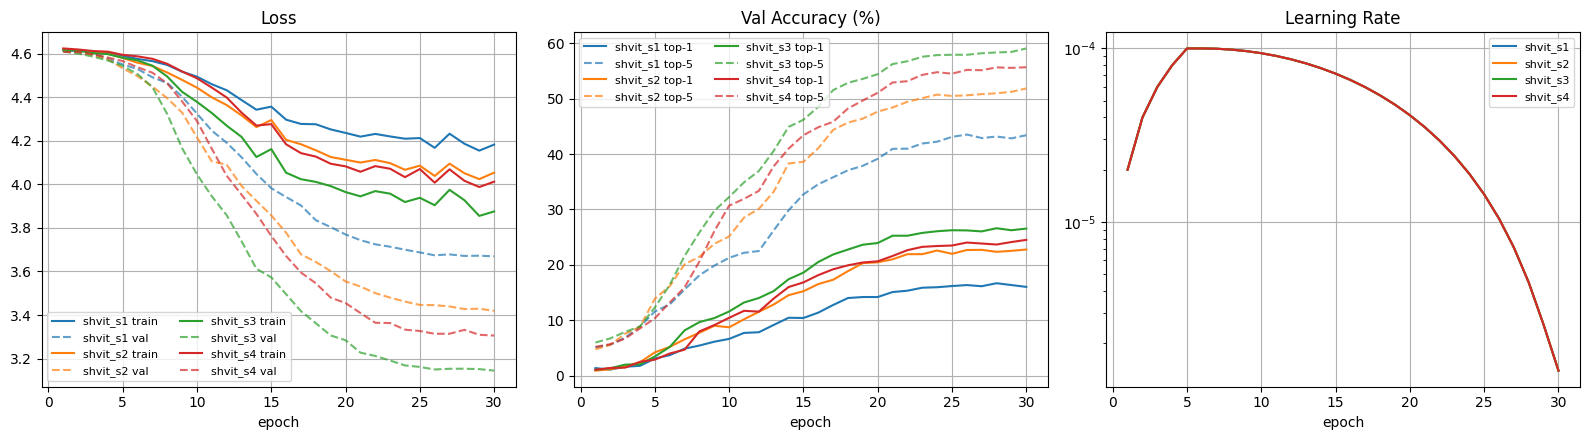


Best val accuracy per model:
model           top-1    top-5  epoch
shvit_s1       16.68%   43.17%     28
shvit_s2       22.77%   51.85%     30
shvit_s3       26.61%   58.36%     28
shvit_s4       24.51%   55.69%     30


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']
COLORS = {'shvit_s1': 'tab:blue', 'shvit_s2': 'tab:orange',
          'shvit_s3': 'tab:green', 'shvit_s4': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

summary = []
for model_name in MODELS:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        print(f'[skip] no log for {model_name}')
        continue

    df = pd.read_csv(csv_path)
    color = COLORS[model_name]

    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train', color=color)
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val',
                 color=color, linestyle='--', alpha=0.7)

    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1', color=color)
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5',
                 color=color, linestyle='--', alpha=0.7)

    axes[2].plot(df['epoch'], df['lr'].astype(float), label=model_name, color=color)

    best = df.loc[df['val_top1'].idxmax()]
    summary.append((model_name, best['val_top1']*100, best['val_top5']*100, int(best['epoch'])))

axes[0].set_title('Loss');           axes[0].set_xlabel('epoch')
axes[0].legend(fontsize=8, ncol=2);  axes[0].grid(True)

axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('epoch')
axes[1].legend(fontsize=8, ncol=2);    axes[1].grid(True)

axes[2].set_title('Learning Rate');    axes[2].set_xlabel('epoch')
axes[2].set_yscale('log');             axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_all.png', dpi=120)
plt.show()

print('\nBest val accuracy per model:')
print(f'{"model":<12} {"top-1":>8} {"top-5":>8} {"epoch":>6}')
for name, t1, t5, ep in summary:
    print(f'{name:<12} {t1:>7.2f}% {t5:>7.2f}% {ep:>6}')
